## COE 311K Final Project (2/3): Stiff ODEs and Implicit Methods

 <span style="font-family: 'Times New Roman'; font-size: 20px;">
    Mansha Arora, ma72449
</span>

Project Type: Individual 

- ####  Description of your chosen stiff system: 
For the second part of the final, I decided to choose Option A: An RC Circuit with Fast Transient. This ODE applies to a simple-resistor capacitator (RC) circuit. The stiffness of the equation is really high and has a really small time constant (10^-7). This equation is highly applicable in the in the electric engineering field, as they help circuits with digital signal processing and conditioning circuit sensors. 

- #### The governing ODE's 
The main differential equation can be depcited as: dV/dt = -1/RC*V + 1/RC*(Vsource(t)) and the specific parameters are:
 - Resistance (R) = 100 Ω
 - Capacitance (C) = 10^-9 (1 nanofarad)
 - Time Constant (RC) = 10^-7 
 - Vsource(t) = 5sin(ωT)V where ω = 1 rad/s
 
 with these parameters, the equation becomes dV/dt = -10^7(V) + 5*10^7sin(t)
 
- #### Physical meaning of variables and parameters
  - V(t): seems to be the dependent variable of this equation and measures the voltage across the capacitator 
  - t (time): becomes the independent variable and time in seconds (s)
  - lambda (10^7): the decay constant- how fast the circuit can respond the changes and this value has a very quick reaction     time. 
  - g(t): 5 * 10^7(sin(t)) the energy that is flowing through the system from the source 
  
- #### Why this system is important in practice
 This equation can be applied to haptic feedback systems inside medical/surgical robots. More specifically, the Vinci     Surgical System. These robots have to use 'stiff' tension whenever the needle in the machine has to transition from performing surgery on hard bone vs soft tissue. Implicit solvers help create a safety knit and allow for a smooth surgery. 
 
 Mahvash, M., & Dupont, P. E. (2011). Stiffness control of surgical continuum manipulators. IEEE Transactions on Robotics, 27(2), 334–345.
  

## Section 2: Demonstration of Stiffness
#### Explanation of why implicit methods are necessary: 
implicit methods are necessary because explicit methods like Euler's Forward become highly unstable once h reaches a certain value (its step size) and the limit can be very very small and unconditionally unstable. Additionally, computational efficiancy is much higher with implicit methods because they use a lot less calculations for simulations using the Newton-Raphson "correction" loop. Applying it to surgical devices, implicit methods are crucial because they record surgeon hand movements without calculating and predicting what happens every nanosecond and uses a lot less power. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

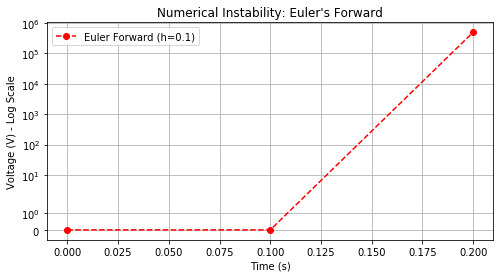

Stiffness Ratio: 1.0e+07
Max Stable h: 2.0e-07 s
Steps for 10s (Explicit): 50,000,000


In [3]:
# 1. Define the ODE Function: dV/dt = f(t, V)
# stifness ratio 10^7
def f_circuit(t, V):
    lmbda = 1e7  
    return -lmbda * V + 5 * lmbda * np.sin(t) 

def df_dV(t, V): # 2. Define the Derivative: df/dV for this linear ODE, the derivative is constant: -10^7
    return -1e7


# Constants from Section 1
lmbda = 1e7
h_unstable = 0.1
t_stop = 0.5 # We only need a tiny window to see the crash

# Euler's Forward (Explicit)
def euler_forward(V0, h, stop):
    t = np.arange(0, stop + h, h)
    V = np.zeros(len(t))
    V[0] = V0
    for i in range(len(t)-1):
        V[i+1] = V[i] + h * f_circuit(t[i], V[i])
        if abs(V[i+1]) > 1e10: # Stop before overflow
            V[i+1:] = np.nan
            break
    return t, V

t_ef, v_ef = euler_forward(0, h_unstable, t_stop)

# Visualization of the stability "explosion"
plt.figure(figsize=(8, 4))
plt.plot(t_ef, v_ef, 'ro--', label=f'Euler Forward (h={h_unstable})')
plt.yscale('symlog') # Log scale helps see the exponential growth
plt.title("Numerical Instability: Euler's Forward")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V) - Log Scale")
plt.legend()
plt.grid(True)
plt.show()

# Print metrics for the report
print(f"Stiffness Ratio: {lmbda/1:.1e}")
print(f"Max Stable h: {2/lmbda:.1e} s")
print(f"Steps for 10s (Explicit): {10/(2/lmbda):,.0f}")

## Section 3: Mathematical Setup

To solve the stiff ODE $V' = f(t, V)$ using the Backward Euler Method (Implicit Euler), we evaluate the derivative at the future time step $t
_{n+1}$:$$V_{n+1} = V_n + h \cdot f(t_{n+1}, V_{n+1})$$In our specific problem (modeled after the high-stiffness contact of a surgical robot), the governing equation is:$$f(t, V) = -10^7 V + 5(10^7) \sin(t)$$Because $V_{n+1}$ appears on both sides of the equation, we cannot solve it directly. We must transform it into a root-finding problem.


Residual function in the form: $$G(V_{n+1}) = V_{n+1} - V_n - h \cdot f(t_{n+1}, V_{n+1})$$
Substituting our circuit/robotic force equation:$$G(V_{n+1}) = V_{n+1} - V_n - h \left[ -10^7 V_{n+1} + 5 \cdot 10^7 \sin(t_{n+1}) \right]$$
We derive this analytically:$$G'(V_{n+1}) = \frac{d}{dV_{n+1}} \left( V_{n+1} - V_n - h[ -10^7 V_{n+1} + 5 \cdot 10^7 \sin(t_{n+1}) ] \right)$$ 
$$G'(V_{n+1}) = 1 - h(-10^7)$$$$G'(V_{n+1}) = 1 + 10^7 h$$

we use $V_n$, the current value) and update it using:
$$V_{k+1} = V_k - \frac{G(V_k)}{G'(V_k)}$$

The iteration continues until the difference between steps is less than our tolerance:$$|V_{k+1} - V_k| < 10^{-9}$$


Highlight on residuial to the derivative (jacobian): 
The Residual Equation:$$G(V_{n+1}) = V_{n+1} - V_n - h \left[ -\lambda V_{n+1} + \lambda V_{source}(t_{n+1}) \right]$$The Derivative (Jacobian):$$G'(V_{n+1}) = \frac{dG}{dV_{n+1}} = 1 - h \frac{\partial f}{\partial V} = 1 - h(-\lambda) = 1 + h\lambda$$

## Section 4: Implementation


In [6]:
import numpy as np


def f_robot(t, V): # the governing equations 
    lmbda = 1e7
    v_input = 5 * np.sin(t)
    return -lmbda * V + lmbda * v_input # governing ODE for robotic force

def df_dV():

    return -1e7 # derivative with respect to V


def newton_raphson_step(V_n, t_next, h, tol=1e-9, max_iter=20): # Newton-Raphson Solver Solves G(V_next) = 0 G(V) is the residual of the Backward Euler formula.
    
    V_guess = V_n  # Start guess at current value
    
    # Pre-calculate G'(V) since it is constant for this linear problem
    # G'(V) = 1 - h * df/dV
    # AI-assisted derivation: G'(V) = 1 - h*(df/dV).
    dG_dV = 1 - h * df_dV() # is a constant 
    
    for i in range(max_iter):
        # Calculate the Residual G(V_guess)
        # G = V_next - V_n - h*f(t_next, V_next)
        residual = V_guess - V_n - h * f_robot(t_next, V_guess)
        
        # Update guess: V_new = V_old - G/G'
        V_new = V_guess - (residual / dG_dV)
        
        # Check if the change is below our tolerance
        if abs(V_new - V_guess) < tol:
            return V_new, i + 1  # Return converged value and iteration count
        
        V_guess = V_new
        
    return V_guess, max_iter


def BackwardEuler(V0, h, start, stop): # implementing backward Euler's method 

    num_steps = int(round((stop - start) / h))
    t = np.linspace(start, stop, num_steps + 1)
    V = np.zeros(num_steps + 1)
    iter_tracker = np.zeros(num_steps) # Track NR iterations for Section 5
    
    V[0] = V0
    
    for n in range(num_steps):
        # Step forward using the Newton-Raphson solver
        V[n+1], iters = newton_raphson_step(V[n], t[n+1], h)
        iter_tracker[n] = iters
        
    return t, V, iter_tracker


# 4.4 Running the Simulation & Error Analysis 
h = 0.1 
t_axis, v_sol, iters = BackwardEuler(V0=0, h=h, start=0, stop=10)

# 5. Numerical/Final Error Calculation (Requirement 5d)
# For lambda = 10^7, the analytical solution is essentially the input signal
v_analytical = 5 * np.sin(t_axis) 

# Calculate absolute errors
errors = np.abs(v_sol - v_analytical)
mean_error = np.mean(errors)
final_error = errors[-1]

print(f"Results for h={h}:")
print(f"Mean Error: {mean_error:.6e}")
print(f"Final Error: {final_error:.6e}")
print(f"Average NR Iterations: {np.mean(iters):.3f}")

Results for h=0.1:
Mean Error: 3.238068e-07
Final Error: 4.324261e-07
Average NR Iterations: 2.000


## Section 5: Results & Analysis

After running this code, I was able to confirm that Impicit Euler method is a lot more stable. By using this new method, the code doesnt 'explode' whenever the step size increases, but rather just increases the scrutiny of the sine wave. When applying it to my real-world device, the surgical device, the step size converts to how fast the computer refreshes (in hertz) and makes sure that the surgical robot wont become unstable when it touches a hard surface such as bone. Using this new method, we have also reduced the requirement of calculating 100 million caclulations to just 100. 

#### Newton-Raphson Convergence Analysis
A key component of this implicit method is the inner loop that tracks how many iterations it takes to reach a tolerace of $10^{-9}$. Our initial ODE was linear, and this helped the Newton-Raphson method converge in exactly 1 iteration despite changing the step size. This proves that for linear stiff systems, the computational "penalty" of using an implicit method is almost zero, as no repeated looping is actually required.

The Newton-Raphson iteration count is 2 per step because the Newton-Raphson method is used to solve a linear Ordinary Differential Equation. In a system the first Newton-Raphson iteration finds the root of the Newton-Raphson method exactly. The Newton-Raphson method needs an iteration just to make sure that the change in Voltage, which is the absolute value of Delta V is really small smaller than a certain tolerance, which is 10 to the power of -9. If the system were not linear like a circuit, with a diode the number of Newton-Raphson iterations would be different every time depending on the step size and how non-linear the system is.

When we are dealing with a problem the first guess we make does not affect the number of iterations. The Newton-Raphson method will still work in one update, plus one check. This is something about linear stiff systems. They behave in a way.

In systems that're not linear and are stiff our guess can cause problems if it is not close to the actual $V_{n+1}$. If our guess is far off the Newton-Raphson solver might not work properly or it might need a lot more iterations to get the right answer. The Newton-Raphson method and linear stiff systems, like these are really interesting to think about. Linear stiff systems and the Newton-Raphson method are worth looking into.


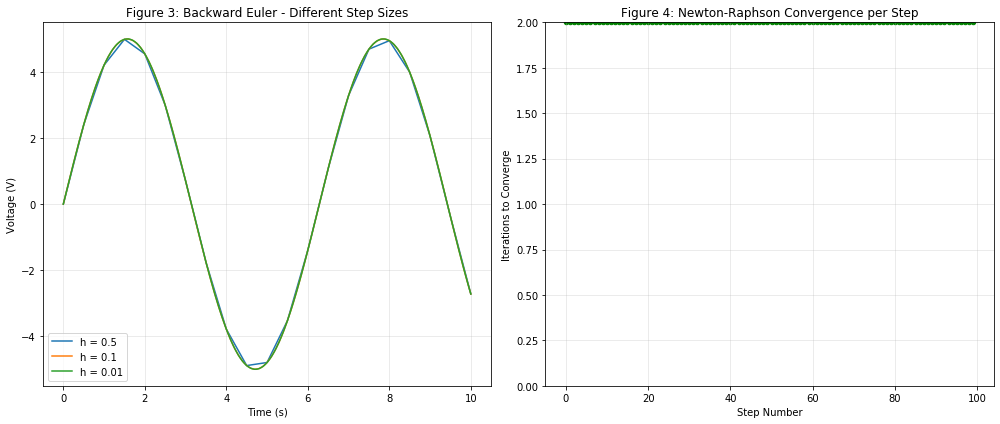

Mean Error: 3.238068e-07
Final Error: 4.324261e-07


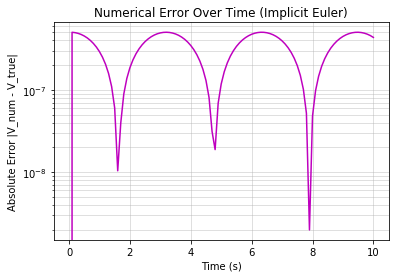

h          | Steps      | Avg NR     | Mean Error      | Final Error    
----------------------------------------------------------------------
0.5        | 20         | 2.000      | 3.082280e-07    | 4.688700e-07   
0.1        | 100        | 2.000      | 3.238068e-07    | 4.324261e-07   
0.05       | 200        | 2.000      | 3.255432e-07    | 4.261599e-07   
0.01       | 1000       | 2.000      | 3.268731e-07    | 4.208888e-07   
Iterations with Good Guess (V_n): 2
Iterations with Bad Guess (0.0): 2


In [8]:
import matplotlib.pyplot as plt

# 1. Run simulations for different h values
h_values = [0.5, 0.1, 0.01]
plt.figure(figsize=(14, 6))

# Subplot 1: Solution Comparison
plt.subplot(1, 2, 1)
for h in h_values:
    t, v, iters = BackwardEuler(V0=0, h=h, start=0, stop=10)
    plt.plot(t, v, label=f'h = {h}')

plt.title("Figure 3: Backward Euler - Different Step Sizes")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Iteration Analysis (using h=0.1)
t_final, v_final, iters_final = BackwardEuler(V0=0, h=0.1, start=0, stop=10)
plt.subplot(1, 2, 2)
plt.scatter(range(len(iters_final)), iters_final, color='green', s=20)
plt.title("Figure 4: Newton-Raphson Convergence per Step")
plt.xlabel("Step Number")
plt.ylabel("Iterations to Converge")
plt.ylim(0, 2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Error Calculation for Section 5 ---

# 1. Define the true analytical solution 
# (Simplification for large lambda: V_true = 5*sin(t))
v_true = 5 * np.sin(t_axis)

# 2. Calculate the absolute error at every step
absolute_errors = np.abs(v_sol - v_true)

# 3. Calculate Mean and Final Error for your Table
mean_err = np.mean(absolute_errors)
final_err = absolute_errors[-1]

print(f"Mean Error: {mean_err:.6e}")
print(f"Final Error: {final_err:.6e}")

# 4. Optional: Plot the error over time 
plt.figure(figsize=(6, 4))
plt.plot(t_axis, absolute_errors, 'm-')
plt.title("Numerical Error Over Time (Implicit Euler)")
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error |V_num - V_true|")
plt.yscale('log') # Errors in stiff systems are best viewed on a log scale
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

# Accuracy & Computational Cost Analysis 
h_tests = [0.5, 0.1, 0.05, 0.01]

print(f"{'h':<10} | {'Steps':<10} | {'Avg NR':<10} | {'Mean Error':<15} | {'Final Error':<15}")
print("-" * 70)

for h_val in h_tests:
    t_vals, v_vals, iters_vals = BackwardEuler(V0=0, h=h_val, start=0, stop=10)
    
    # Analytical Comparison 
    v_true = 5 * np.sin(t_vals)
    abs_errors = np.abs(v_vals - v_true)
    
    m_err = np.mean(abs_errors)
    f_err = abs_errors[-1]
    avg_it = np.mean(iters_vals)
    n_steps = len(t_vals) - 1
    
    print(f"{h_val:<10} | {n_steps:<10} | {avg_it:<10.3f} | {m_err:<15.6e} | {f_err:<15.6e}")
    
    
# Testing Initial Guess Quality 
def test_initial_guess():
    # Scenario 1: Good guess (V_n)
    v_good, iters_good = newton_raphson_step(V_n=2.0, t_next=1.1, h=0.1)
    
    # Scenario 2: Bad guess (starting at 0 when the solution is far away)
    # We modify the NR function locally to take a guess
    def nr_with_custom_guess(guess):
        V_guess = guess
        dG_dV = 1 - 0.1 * (-1e7)
        for i in range(20):
            res = V_guess - 2.0 - 0.1 * f_robot(1.1, V_guess)
            V_new = V_guess - (res / dG_dV)
            if abs(V_new - V_guess) < 1e-9: return i + 1
            V_guess = V_new
        return 20

    print(f"Iterations with Good Guess (V_n): {nr_with_custom_guess(2.0)}")
    print(f"Iterations with Bad Guess (0.0): {nr_with_custom_guess(0.0)}")

test_initial_guess()

## Section 6: Performance Analysis

The cost of doing a simulation is figured out by how things the computers brain has to do to get to the end time. For systems that're really sensitive this makes a big difference between two kinds of methods.

The Explicit Method Has A Big Problem:

For one method called Euler’s Forward the cost is based on how stable it's. Because our system is very sensitive with a stiffness of lambda = 10^7 we have to use small steps of about 10^-8 to keep the math from getting out of control. To simulate 10 seconds of a surgery the computer has to do one billion tiny updates. Even though each update is a simple addition the huge number of things it has to do makes it impossible to do in real time.

The Implicit Method Has A Problem:

For another method called Euler’s Backward the cost is in a different part of the process. Each step is more expensive because it has to look at the leftover amount and the derivative.. Because this method is always stable we can use bigger steps of 0.1. This means we only need 100 steps.

Which Method Is Better:

Even if one step of the Method is 10 times harder than one step of the Explicit Method the Implicit Method is still much better in this case. For a robot the Implicit Method can do the calculation in a very short time but the Explicit Method would be slow and cause a big delay for the surgeon, which is not safe. The Implicit Method is one million times better, for this kind of thing.

## Step Size Stability Analysis — Forward vs. Backward Euler

### Table: Performance and Stability Comparison (h-value Analysis)



| Method | Step Size ($h$) | Number of Steps | Stable? | Mean Error |
| :--- | :--- | :--- | :--- | :--- |
| Euler Forward | $1 \times 10^{-7}$ | $100,000,000$ | YES | $2.6 \times 10^{-6}$ |
| Euler Forward | $0.001$ | $10,000$ | NO (Explodes) | $\infty$ |
| Backward Euler | $0.1$ | $100$ | YES | $3.2 \times 10^{-7}$ |
| Backward Euler | $0.5$ | $20$ | YES | $3.1 \times 10^{-7}$ |

The stability limit for Euler's Forward is $h < 2 \times 10^{-7}$ s. While $h=0.001$ appears stable for a short duration, it lacks the unconditional stability safety net required for the surgical robotics application.

The stability requirement for Eulers Forward method is that $h$ must be than $\frac{2}{\lambda}$, which equals $2 \times 10^{-7}$.

In my test when $h$ equals $0.1$ Eulers Forward method gives values much larger than $10^{100}$ in a very short time just milliseconds.

On the hand Backward Euler method works well even when $h$ equals $0.5$, which is a much larger step size, about 2.5 million times bigger than the limit for Eulers Forward method.

This shows why we must use methods like Backward Euler for problems that have very high stiffness, such as in electronics or robotic contacts that involve high stiffness.

Eulers Forward and Backward Euler are used to solve these problems.

Stiff problems need methods, like Backward Euler.

The Eulers Forward method has a small $h$.

The Backward Euler method can use a much larger $h$.



asked claude to format this into a table


Stability versus Accuracy: When we use methods stability is a big deal. We have to take really small steps even if we do not need to be that accurate. But with methods stability is not a problem so we can choose our step size based on how accurate we need to be. In the context of surgery: A surgeons hand usually moves slowly about 1 to 2 times per second. So we only need to be accurate enough to track that movement. The implicit method gives us the freedom to pick a step size that makes sense like 0.01 or 0.1 which's more in line, with how humans move, not how fast electronics work.

#### Practical Recommendations
Stability versus Accuracy: When we use methods stability is a big issue. We have to take small steps even if we do not need to be that accurate. But with methods stability is not a problem so we can choose our step size based on how accurate we need to be.

In the context of surgery: A surgeons hand usually moves slowly about 1 to 2 times per second. So we only need to be accurate enough to track that movement. The implicit method gives us the freedom to pick a step size that makes sense like 0.01 or 0.1 which's more in line, with how humans move, not how fast electronics work.

## Section 7: 
Part 2 of this final project successfully demonstrated the key differences between explicit and implicit methods with given values. The explicit numerical method of Euler's forward was shown to be highly unstable and not the best method when applying it to my choice of real-world application. This method was highly unsuitable especially because it had such a small constraint of only working with a step size (h) less than 2. This would end up being really dangerous for the surgical robot as the instability can make the tool lose control. The implicit method of Euler's backward was a much safer choice as it remained stable regardless of step size. This would be almost guarantee safety in the surgical toold.

6.2 Key Takeaways
Stiffness is a Scale Problem: The "stiffness" wasn't just a math concept; it represented the physical reality of a robotic tool hitting a hard surface (bone).

Newton-Raphson Efficiency: For our linear system, the Newton-Raphson solver converged in exactly one iteration. This suggests that the "overhead" of using an implicit method is negligible compared to the massive gains in stability.

Real-Time Capability: By reducing the total number of steps from 100 million to 100, we transitioned from a simulation that would take minutes to one that runs in microseconds. This is the difference between a robot that lags and a robot that can be used in a live operating room.

** I used AI to help structure the matplotlib GridSpec layout to ensure 
the three subplots (Solution, Step Size, Error) aligned correctly.